

Training: Baseline (1 hidden, 128)
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8896 - loss: 0.3988 - val_accuracy: 0.9383 - val_loss: 0.2251
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9458 - loss: 0.1894 - val_accuracy: 0.9550 - val_loss: 0.1591
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9621 - loss: 0.1356 - val_accuracy: 0.9619 - val_loss: 0.1310
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9705 - loss: 0.1067 - val_accuracy: 0.9655 - val_loss: 0.1159
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9759 - loss: 0.0853 - val_accuracy: 0.9678 - val_loss: 0.1072
Test Accuracy: 0.9684

Training: Wider (2 hidden, 256-128)
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9127 - loss: 0.3058 - val_accuracy: 0.9579 - val_loss: 0.1458
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9649 - loss: 0.1181 - val_accuracy: 0.9680 - val_loss: 0.1036
Epoch 3/5
375/3

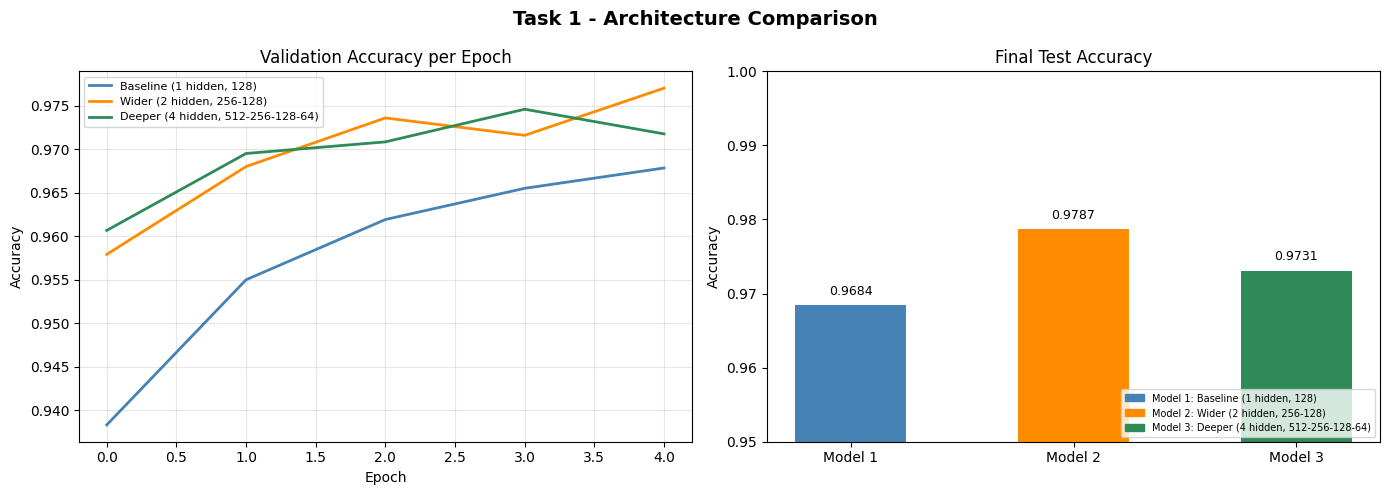


Plot saved as task1_architecture_comparison.png


In [5]:
"""
Assignment 5 - Task 1
Modify the architecture by adding more hidden layers and neurons.
See how it affects accuracy.
"""

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

# Clear any cached Keras state from previous runs
tf.keras.backend.clear_session()

# ── Load & preprocess data ──────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test  = X_test.reshape(X_test.shape[0],  28, 28, 1).astype('float32') / 255


# ── Helper: build, train, and evaluate a model ──────────────────────────────
def build_and_train(layers_config, epochs=5):
    """
    layers_config: list of (units, activation) tuples for hidden layers.
    The output layer (10 neurons, softmax) is added automatically.
    """
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))

    for units, activation in layers_config:
        model.add(Dense(units, activation=activation))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return history, test_acc


# ── Define three architectures to compare ───────────────────────────────────
configs = [
    {
        'label': 'Baseline (1 hidden, 128)',
        'layers': [(128, 'relu')]
    },
    {
        'label': 'Wider (2 hidden, 256-128)',
        'layers': [(256, 'relu'), (128, 'relu')]
    },
    {
        'label': 'Deeper (4 hidden, 512-256-128-64)',
        'layers': [(512, 'relu'), (256, 'relu'), (128, 'relu'), (64, 'relu')]
    },
]

# ── Train all models ─────────────────────────────────────────────────────────
histories  = []
accuracies = []

for cfg in configs:
    print(f"\n{'='*50}")
    print(f"Training: {cfg['label']}")
    tf.keras.backend.clear_session()   # reset between models to avoid name collisions
    hist, acc = build_and_train(cfg['layers'], epochs=5)
    histories.append(hist)
    accuracies.append(acc)
    print(f"Test Accuracy: {acc:.4f}")


# ── Plot results ─────────────────────────────────────────────────────────────
colors = ['steelblue', 'darkorange', 'seagreen']
labels = [cfg['label'] for cfg in configs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 1 - Architecture Comparison', fontsize=14, fontweight='bold')

# Left: validation accuracy per epoch
for hist, label, color in zip(histories, labels, colors):
    axes[0].plot(hist.history['val_accuracy'], label=label, color=color, linewidth=2)
axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: final test accuracy bar chart
bars = axes[1].bar(
    [f'Model {i+1}' for i in range(len(accuracies))],
    accuracies,
    color=colors,
    width=0.5
)
axes[1].set_title('Final Test Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.95, 1.0)
for bar, acc in zip(bars, accuracies):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{acc:.4f}',
        ha='center', va='bottom', fontsize=9
    )
axes[1].legend(
    [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors],
    [f'Model {i+1}: {l}' for i, l in enumerate(labels)],
    fontsize=7,
    loc='lower right'
)

plt.tight_layout()
plt.savefig('task1_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as task1_architecture_comparison.png")


Training with activation: RELU
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9136 - loss: 0.3042 - val_accuracy: 0.9564 - val_loss: 0.1535
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9644 - loss: 0.1181 - val_accuracy: 0.9675 - val_loss: 0.1111
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9768 - loss: 0.0768 - val_accuracy: 0.9721 - val_loss: 0.0969
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9833 - loss: 0.0573 - val_accuracy: 0.9744 - val_loss: 0.0853
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0397 - val_accuracy: 0.9726 - val_loss: 0.0906
Test Accuracy (relu): 0.9728

Training with activation: SIGMOID
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8242 - loss: 0.7090 - val_accuracy: 0.9186 - val_loss: 0.2898
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9235 - loss: 0.2617 - val_accuracy: 0.9397 - val_loss: 0.2112
Epoch 3/5
375/3

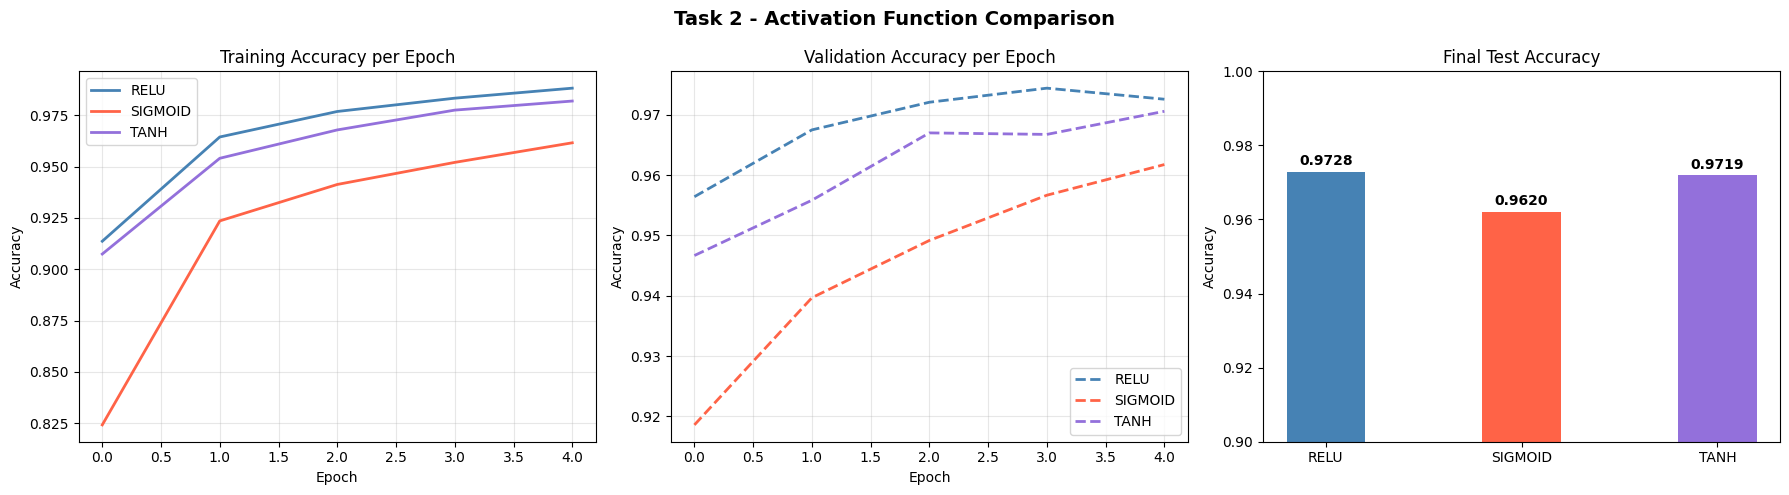


Plot saved as task2_activation_comparison.png


In [6]:
"""
Assignment 5 - Task 2
Experiment with different activation functions like Sigmoid in the hidden layers.
"""

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

tf.keras.backend.clear_session()

# ── Load & preprocess data ──────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test  = X_test.reshape(X_test.shape[0],  28, 28, 1).astype('float32') / 255


# ── Helper: build, train, and evaluate a model ──────────────────────────────
def build_and_train(activation, epochs=5):
    """
    Builds a 2-hidden-layer network using the given activation function.
    Architecture is kept identical across all runs so only the
    activation function changes.
    """
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(256, activation=activation))
    model.add(Dense(128, activation=activation))
    model.add(Dense(10,  activation='softmax'))   # output always softmax

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return history, test_acc


# ── Activation functions to compare ─────────────────────────────────────────
activations = ['relu', 'sigmoid', 'tanh']

histories  = []
accuracies = []

for act in activations:
    print(f"\n{'='*50}")
    print(f"Training with activation: {act.upper()}")
    tf.keras.backend.clear_session()
    hist, acc = build_and_train(act, epochs=5)
    histories.append(hist)
    accuracies.append(acc)
    print(f"Test Accuracy ({act}): {acc:.4f}")


# ── Plot results ─────────────────────────────────────────────────────────────
colors = ['steelblue', 'tomato', 'mediumpurple']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Task 2 - Activation Function Comparison', fontsize=14, fontweight='bold')

# Left: training accuracy
for hist, act, color in zip(histories, activations, colors):
    axes[0].plot(hist.history['accuracy'], label=act.upper(), color=color, linewidth=2)
axes[0].set_title('Training Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Middle: validation accuracy
for hist, act, color in zip(histories, activations, colors):
    axes[1].plot(hist.history['val_accuracy'], label=act.upper(), color=color,
                 linewidth=2, linestyle='--')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Right: final test accuracy bar chart
bars = axes[2].bar(
    [act.upper() for act in activations],
    accuracies,
    color=colors,
    width=0.4
)
axes[2].set_title('Final Test Accuracy')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0.90, 1.0)
for bar, acc in zip(bars, accuracies):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{acc:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('task2_activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as task2_activation_comparison.png")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9125 - loss: 0.3016 - val_accuracy: 0.9590 - val_loss: 0.1428
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9661 - loss: 0.1134 - val_accuracy: 0.9698 - val_loss: 0.1027
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9771 - loss: 0.0752 - val_accuracy: 0.9725 - val_loss: 0.0917
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9846 - loss: 0.0520 - val_accuracy: 0.9737 - val_loss: 0.0881
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9881 - loss: 0.0392 - val_accuracy: 0.9758 - val_loss: 0.0805
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9768 - val_loss: 0.0821
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9926 - loss: 0.0238 - val_accuracy: 0.9744 - val_loss: 0.0968
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9938 - loss: 0.0194 - val_accuracy: 0.

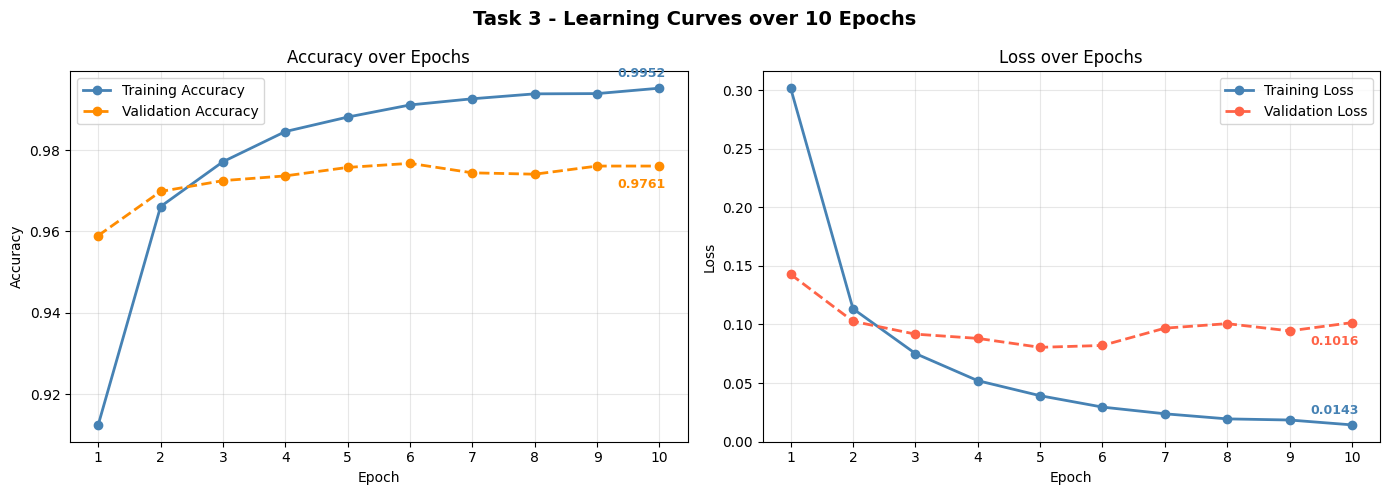


Plot saved as task3_learning_curves.png


In [7]:
"""
Assignment 5 - Task 3
Try training for 10 epochs and plot the loss and accuracy over time
to observe the learning curve.
"""

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

tf.keras.backend.clear_session()

# ── Load & preprocess data ──────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test  = X_test.reshape(X_test.shape[0],  28, 28, 1).astype('float32') / 255

# ── Build the model ──────────────────────────────────────────────────────────
model = Sequential()
model.add(Flatten(input_shape=(28, 28, 1)))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10,  activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Train for 10 epochs ──────────────────────────────────────────────────────
EPOCHS = 10

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# ── Evaluate on test set ─────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy : {test_acc:.4f}")
print(f"Final Test Loss     : {test_loss:.4f}")

# ── Plot learning curves ─────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3 - Learning Curves over 10 Epochs', fontsize=14, fontweight='bold')

# Left: Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],
             label='Training Accuracy', color='steelblue', linewidth=2, marker='o')
axes[0].plot(epochs_range, history.history['val_accuracy'],
             label='Validation Accuracy', color='darkorange', linewidth=2,
             marker='o', linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Annotate final values
axes[0].annotate(f"{history.history['accuracy'][-1]:.4f}",
                 xy=(EPOCHS, history.history['accuracy'][-1]),
                 xytext=(-30, 8), textcoords='offset points',
                 color='steelblue', fontsize=9, fontweight='bold')
axes[0].annotate(f"{history.history['val_accuracy'][-1]:.4f}",
                 xy=(EPOCHS, history.history['val_accuracy'][-1]),
                 xytext=(-30, -16), textcoords='offset points',
                 color='darkorange', fontsize=9, fontweight='bold')

# Right: Loss
axes[1].plot(epochs_range, history.history['loss'],
             label='Training Loss', color='steelblue', linewidth=2, marker='o')
axes[1].plot(epochs_range, history.history['val_loss'],
             label='Validation Loss', color='tomato', linewidth=2,
             marker='o', linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Annotate final values
axes[1].annotate(f"{history.history['loss'][-1]:.4f}",
                 xy=(EPOCHS, history.history['loss'][-1]),
                 xytext=(-30, 8), textcoords='offset points',
                 color='steelblue', fontsize=9, fontweight='bold')
axes[1].annotate(f"{history.history['val_loss'][-1]:.4f}",
                 xy=(EPOCHS, history.history['val_loss'][-1]),
                 xytext=(-30, -16), textcoords='offset points',
                 color='tomato', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('task3_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as task3_learning_curves.png")

In [ ]:
## Instructor Tasks Examples

In [8]:
# Task 1
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the data
# Flatten 28x28 images into 784-dimensional vectors and normalize pixel values
X_train = X_train.reshape((X_train.shape[0], 28 * 28)).astype('float32') / 255
X_test = X_test.reshape((X_test.shape[0], 28 * 28)).astype('float32') / 255

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Step 1: Define the baseline neural network architecture with one hidden layer
def build_baseline_model():
    model = models.Sequential()
    model.add(layers.Dense(128, activation='relu', input_shape=(28 * 28,)))
    model.add(layers.Dense(10, activation='softmax'))  # Output layer
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 2: Define the modified neural network architecture with more hidden layers and neurons
def build_modified_model():
    model = models.Sequential()
    model.add(layers.Dense(256, activation='relu', input_shape=(28 * 28,)))  # First hidden layer
    model.add(layers.Dense(128, activation='relu'))  # Second hidden layer
    model.add(layers.Dense(64, activation='relu'))   # Third hidden layer
    model.add(layers.Dense(10, activation='softmax'))  # Output layer
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 3: Train and evaluate the baseline model
baseline_model = build_baseline_model()
history_baseline = baseline_model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=2)
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)

# Step 4: Train and evaluate the modified model
modified_model = build_modified_model()
history_modified = modified_model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=2)
modified_loss, modified_accuracy = modified_model.evaluate(X_test, y_test, verbose=0)

# Output the accuracy for both models
print(f"Baseline Model Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Modified Model Accuracy: {modified_accuracy * 100:.2f}%")

Epoch 1/10


C:\Python\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


469/469 - 2s - 4ms/step - accuracy: 0.9014 - loss: 0.3597 - val_accuracy: 0.9470 - val_loss: 0.1852
Epoch 2/10
469/469 - 1s - 3ms/step - accuracy: 0.9549 - loss: 0.1594 - val_accuracy: 0.9615 - val_loss: 0.1307
Epoch 3/10
469/469 - 1s - 3ms/step - accuracy: 0.9671 - loss: 0.1144 - val_accuracy: 0.9673 - val_loss: 0.1064
Epoch 4/10
469/469 - 1s - 3ms/step - accuracy: 0.9743 - loss: 0.0894 - val_accuracy: 0.9706 - val_loss: 0.0945
Epoch 5/10
469/469 - 1s - 3ms/step - accuracy: 0.9793 - loss: 0.0726 - val_accuracy: 0.9733 - val_loss: 0.0884
Epoch 6/10
469/469 - 1s - 3ms/step - accuracy: 0.9825 - loss: 0.0610 - val_accuracy: 0.9757 - val_loss: 0.0813
Epoch 7/10
469/469 - 1s - 3ms/step - accuracy: 0.9852 - loss: 0.0512 - val_accuracy: 0.9774 - val_loss: 0.0747
Epoch 8/10
469/469 - 1s - 3ms/step - accuracy: 0.9882 - loss: 0.0429 - val_accuracy: 0.9763 - val_loss: 0.0782
Epoch 9/10
469/469 - 1s - 3ms/step - accuracy: 0.9894 - loss: 0.0368 - val_accuracy: 0.9763 - val_loss: 0.0736
Epoch 10/10


In [9]:
# Task 2
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the data
# Flatten 28x28 images into 784-dimensional vectors and normalize pixel values
X_train = X_train.reshape((X_train.shape[0], 28 * 28)).astype('float32') / 255
X_test = X_test.reshape((X_test.shape[0], 28 * 28)).astype('float32') / 255

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Step 1: Define a neural network with ReLU activation
def build_relu_model():
    model = models.Sequential()
    model.add(layers.Dense(128, activation='relu', input_shape=(28 * 28,)))  # Hidden layer with ReLU
    model.add(layers.Dense(10, activation='softmax'))  # Output layer
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 2: Define a neural network with Sigmoid activation
def build_sigmoid_model():
    model = models.Sequential()
    model.add(layers.Dense(128, activation='sigmoid', input_shape=(28 * 28,)))  # Hidden layer with Sigmoid
    model.add(layers.Dense(10, activation='softmax'))  # Output layer
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 3: Train and evaluate the model with ReLU activation
relu_model = build_relu_model()
history_relu = relu_model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=2)
relu_loss, relu_accuracy = relu_model.evaluate(X_test, y_test, verbose=0)

# Step 4: Train and evaluate the model with Sigmoid activation
sigmoid_model = build_sigmoid_model()
history_sigmoid = sigmoid_model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=2)
sigmoid_loss, sigmoid_accuracy = sigmoid_model.evaluate(X_test, y_test, verbose=0)

# Output the accuracy for both models
print(f"ReLU Model Accuracy: {relu_accuracy * 100:.2f}%")
print(f"Sigmoid Model Accuracy: {sigmoid_accuracy * 100:.2f}%")

Epoch 1/10
469/469 - 2s - 4ms/step - accuracy: 0.9005 - loss: 0.3580 - val_accuracy: 0.9489 - val_loss: 0.1816
Epoch 2/10
469/469 - 1s - 3ms/step - accuracy: 0.9542 - loss: 0.1603 - val_accuracy: 0.9610 - val_loss: 0.1312
Epoch 3/10
469/469 - 1s - 3ms/step - accuracy: 0.9664 - loss: 0.1167 - val_accuracy: 0.9704 - val_loss: 0.1054
Epoch 4/10
469/469 - 1s - 2ms/step - accuracy: 0.9735 - loss: 0.0912 - val_accuracy: 0.9708 - val_loss: 0.0983
Epoch 5/10
469/469 - 1s - 2ms/step - accuracy: 0.9786 - loss: 0.0737 - val_accuracy: 0.9755 - val_loss: 0.0857
Epoch 6/10
469/469 - 1s - 2ms/step - accuracy: 0.9823 - loss: 0.0613 - val_accuracy: 0.9761 - val_loss: 0.0841
Epoch 7/10
469/469 - 1s - 3ms/step - accuracy: 0.9853 - loss: 0.0517 - val_accuracy: 0.9749 - val_loss: 0.0815
Epoch 8/10
469/469 - 1s - 3ms/step - accuracy: 0.9875 - loss: 0.0434 - val_accuracy: 0.9769 - val_loss: 0.0738
Epoch 9/10
469/469 - 1s - 3ms/step - accuracy: 0.9897 - loss: 0.0372 - val_accuracy: 0.9769 - val_loss: 0.0746
E

Epoch 1/10
469/469 - 2s - 4ms/step - accuracy: 0.9007 - loss: 0.3627 - val_accuracy: 0.9444 - val_loss: 0.1931
Epoch 2/10
469/469 - 1s - 3ms/step - accuracy: 0.9528 - loss: 0.1674 - val_accuracy: 0.9584 - val_loss: 0.1354
Epoch 3/10
469/469 - 1s - 3ms/step - accuracy: 0.9664 - loss: 0.1193 - val_accuracy: 0.9654 - val_loss: 0.1134
Epoch 4/10
469/469 - 1s - 2ms/step - accuracy: 0.9733 - loss: 0.0928 - val_accuracy: 0.9705 - val_loss: 0.0974
Epoch 5/10
469/469 - 1s - 3ms/step - accuracy: 0.9785 - loss: 0.0737 - val_accuracy: 0.9740 - val_loss: 0.0852
Epoch 6/10
469/469 - 1s - 2ms/step - accuracy: 0.9825 - loss: 0.0610 - val_accuracy: 0.9772 - val_loss: 0.0801
Epoch 7/10
469/469 - 1s - 3ms/step - accuracy: 0.9854 - loss: 0.0506 - val_accuracy: 0.9773 - val_loss: 0.0736
Epoch 8/10
469/469 - 1s - 3ms/step - accuracy: 0.9882 - loss: 0.0422 - val_accuracy: 0.9771 - val_loss: 0.0726
Epoch 9/10
469/469 - 1s - 2ms/step - accuracy: 0.9899 - loss: 0.0361 - val_accuracy: 0.9789 - val_loss: 0.0690
E

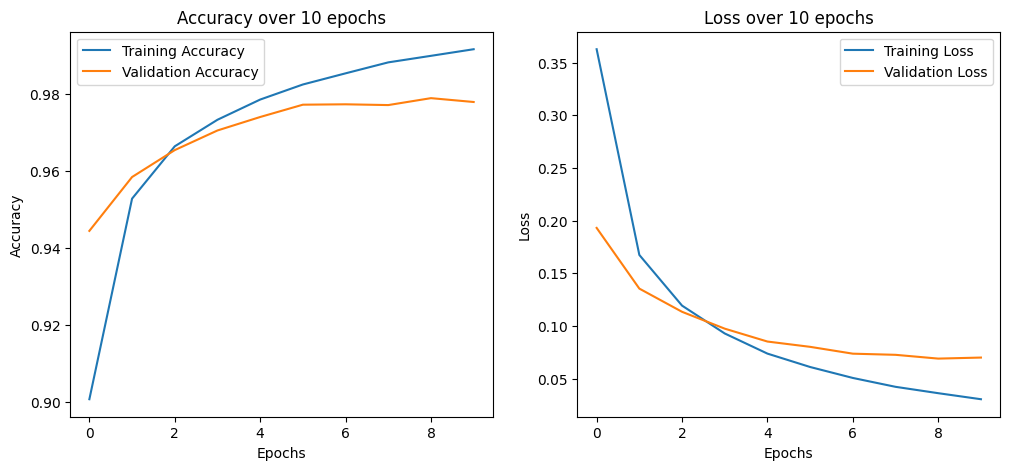

In [10]:
# Task 3
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess the data
# Flatten 28x28 images into 784-dimensional vectors and normalize pixel values
X_train = X_train.reshape((X_train.shape[0], 28 * 28)).astype('float32') / 255
X_test = X_test.reshape((X_test.shape[0], 28 * 28)).astype('float32') / 255

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Define the neural network model with ReLU activation
def build_model():
    model = models.Sequential()
    model.add(layers.Dense(128, activation='relu', input_shape=(28 * 28,)))  # Hidden layer with ReLU
    model.add(layers.Dense(10, activation='softmax'))  # Output layer
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train the model for 10 epochs
model = build_model()
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test), verbose=2)

# Plot the loss and accuracy over the epochs
def plot_learning_curves(history):
    # Plot accuracy
    plt.figure(figsize=(12, 5))

    # Plot Accuracy over time
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over 10 epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss over time
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over 10 epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Call the function to plot the learning curves
plot_learning_curves(history)